# Semester Project: Fake News Detection Using Logistic Regression
## By: SP24-BAI-026 and SP24-BAI-062
### Import Libraries:

In [24]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset:

In [25]:
# Loading datasets
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

# Adding labels
fake["label"] = 0   
real["label"] = 1   

# Combining datasets
data = pd.concat([fake, real], axis=0)

# Shuffling data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


### Mark Required columns:

In [26]:
# Required columns
data = data[["title", "text", "subject", "date", "label"]]
print("Dataset shape:", data.shape)

Dataset shape: (44898, 5)


### Dataset Size Adjustment:

In [27]:
# Reducing dataset size for better performance (>= 900 rows)
data = data.sample(n=3000, random_state=42).reset_index(drop=True)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Handling missing values
data["clean_text"] = (
    data["title"].fillna("") + " " + data["text"].fillna("")
)

# Applying text cleaning
data["clean_text"] = data["clean_text"].apply(clean_text)

# Previewing cleaned data
data.head()

,title,text,subject,date,label,clean_text
0,It’s Really Happening: Trump Adviser Lays Out...,"Well, that didn t take long. In the short time...",News,"November 16, 2016",0,its really happening trump adviser lays out p...
1,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",1,republican attempt to deflect trumprussia prob...
2,Trump says churches should get FEMA funds for ...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"September 9, 2017",1,trump says churches should get fema funds for ...
3,Trump Loves To Say The New York Times Is ‘Fai...,Print journalism and longstanding papers have ...,News,"August 7, 2017",0,trump loves to say the new york times is fail...
4,House Speaker Ryan briefed Trump on healthcare...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"March 24, 2017",1,house speaker ryan briefed trump on healthcare...


### Feature Engineering:

In [28]:
# 1: Word count
data["word_count"] = data["clean_text"].apply(lambda x: len(x.split()))

# 2: Character count
data["char_count"] = data["clean_text"].apply(len)

# 3: Average word length
data["avg_word_len"] = data["char_count"] / data["word_count"]

# 4: Title length
data["title_len"] = data["title"].apply(len)

# 5: Uppercase words count
data["upper_words"] = data["text"].apply(lambda x: sum(1 for w in str(x).split() if w.isupper()))

# Encoding subject
data["subject_encoded"] = data["subject"].factorize()[0]

data.head()

,title,text,subject,date,label,clean_text,word_count,char_count,avg_word_len,title_len,upper_words,subject_encoded
0,It’s Really Happening: Trump Adviser Lays Out...,"Well, that didn t take long. In the short time...",News,"November 16, 2016",0,its really happening trump adviser lays out p...,533,3263,6.121951,80,1,0
1,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",1,republican attempt to deflect trumprussia prob...,553,3663,6.623870,73,8,1
2,Trump says churches should get FEMA funds for ...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"September 9, 2017",1,trump says churches should get fema funds for ...,326,2020,6.196319,62,8,1
3,Trump Loves To Say The New York Times Is ‘Fai...,Print journalism and longstanding papers have ...,News,"August 7, 2017",0,trump loves to say the new york times is fail...,315,1897,6.022222,115,5,0
4,House Speaker Ryan briefed Trump on healthcare...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"March 24, 2017",1,house speaker ryan briefed trump on healthcare...,127,730,5.748031,71,4,1


### Applying TF-IDF: Feature Extraction

In [29]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

X_tfidf = tfidf.fit_transform(data["clean_text"])

# Extra numerical features
X_numeric = data[
    ["word_count", "char_count", "avg_word_len",
     "title_len", "upper_words", "subject_encoded"]
]

# Combining TF-IDF + numerical features
from scipy.sparse import hstack
X = hstack([X_tfidf, X_numeric])

y = data["label"]

### Splitting sample dataset:

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2400
Testing samples: 600


### Using Logistic Regression:

In [31]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Logistic Regression with liblinear solver:

In [32]:
model = LogisticRegression(
    max_iter=3000,
    solver="liblinear"
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,3000
,multi_class,'deprecated'


### Classification report of model:

In [33]:
y_pred = model.predict(X_test)

# Accuracy of model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report on model
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.965

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       310
           1       0.97      0.96      0.96       290

    accuracy                           0.96       600
   macro avg       0.97      0.96      0.96       600
weighted avg       0.97      0.96      0.96       600



### Confusion Matrix Heatmap:

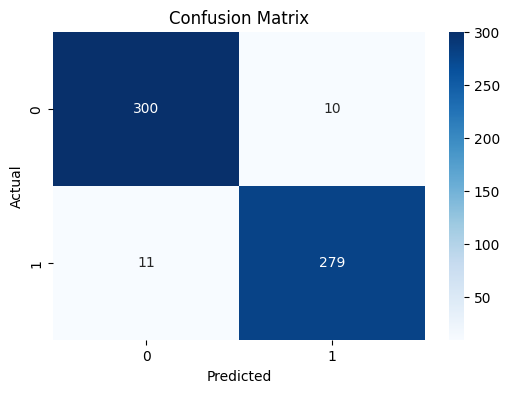

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Top words for classification:

In [35]:
# Top words influencing predictions
feature_names = tfidf.get_feature_names_out()

coefficients = model.coef_[0][:len(feature_names)]

top_fake = np.argsort(coefficients)[:10]
top_real = np.argsort(coefficients)[-10:]

print("Top words that indicates FAKE news:")
print(feature_names[top_fake])

print("\nTop words that indicates REAL news:")
print(feature_names[top_real])

Top words that indicates FAKE news:
['video' 'hillary' 'wire' 'image' 'just' 'trump' 'obama' 'like' 'st'
 'watch']

Top words that indicates REAL news:
['north' 'thursday' 'friday' 'wednesday' 'tax' 'washington' 'minister'
 'trumps' 'reuters' 'said']


### Horizontal bar distribution for Top words for classification

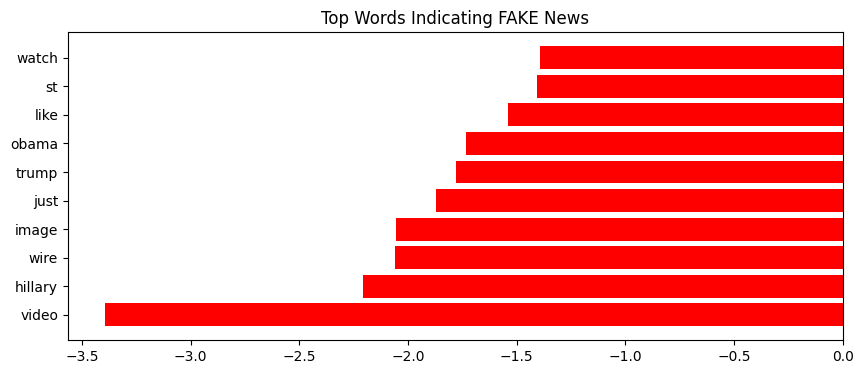

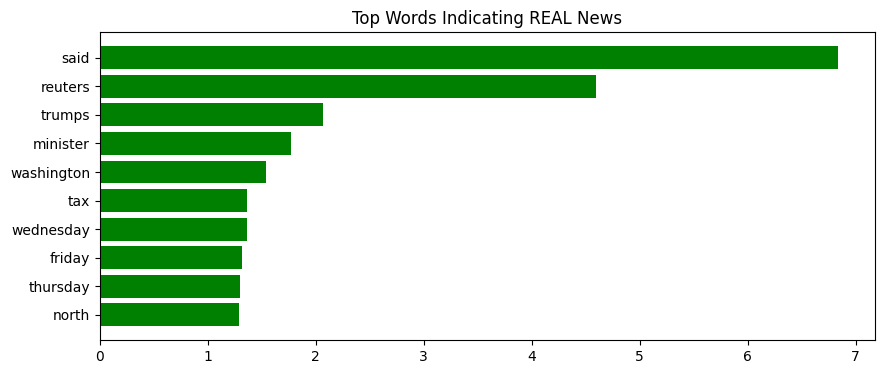

In [36]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0][:len(feature_names)]

# For Fake News
top_fake = np.argsort(coefficients)[:10]
# For Real News
top_real = np.argsort(coefficients)[-10:]

plt.figure(figsize=(10,4))
plt.barh(feature_names[top_fake], coefficients[top_fake], color='red')
plt.title("Top Words Indicating FAKE News")
plt.show()

plt.figure(figsize=(10,4))
plt.barh(feature_names[top_real], coefficients[top_real], color='green')
plt.title("Top Words Indicating REAL News")
plt.show()